In [1]:
import xarray as xr
import xesmf as xe
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =========================
# FUNCTION
# =========================

def area_weighted_mean(da, area):
    """
    Compute area-weighted mean of a DataArray.

    Parameters
    ----------
    da : xarray.DataArray
        Variable to average.
    area : xarray.DataArray
        Grid-cell area (TAREA).

    Returns
    -------
    float
    """
    # Surface layer only if needed
    if "z_t" in da.dims:
        da = da.isel(z_t=0)
    elif "z_t_150m" in da.dims:
        da = da.isel(z_t_150m=0)

    # Ignore NaNs in both variable and area
    weights = area.where(da.notnull())
    weights = weights.fillna(0)

    return da.weighted(weights).mean(("nlat", "nlon")).item()

def process_dataset(ds_list):

    n_ds = len(ds_list)

    sp_mean = np.full((3, n_ds), np.nan)
    diat_mean = np.full((4, n_ds), np.nan)
    diaz_mean = np.full((2, n_ds), np.nan)

    for d, ds in enumerate(ds_list):

        area = ds["TAREA"]

        # Small phytoplankton
        sp_mean[0, d] = 1 - area_weighted_mean(ds["sp_Fe_lim"], area)
        sp_mean[1, d] = 1 - area_weighted_mean(ds["sp_P_lim"], area)
        sp_mean[2, d] = 1 - area_weighted_mean(ds["sp_N_lim"], area)

        # Diatoms
        diat_mean[0, d] = 1 - area_weighted_mean(ds["diat_Fe_lim"], area)
        diat_mean[1, d] = 1 - area_weighted_mean(ds["diat_P_lim"], area)
        diat_mean[2, d] = 1 - area_weighted_mean(ds["diat_N_lim"], area)
        diat_mean[3, d] = 1 - area_weighted_mean(ds["diat_SiO3_lim"], area)

        # Diazotrophs
        diaz_mean[0, d] = 1 - area_weighted_mean(ds["diaz_Fe_lim"], area)
        diaz_mean[1, d] = 1 - area_weighted_mean(ds["diaz_P_lim"], area)

    return sp_mean, diat_mean, diaz_mean

In [3]:
# =========================
# MAIN
# =========================

ds1 = xr.open_dataset("data/gdev1420.pop.h.0281_0300.nc")
ds2 = xr.open_dataset("data/gdev1440.pop.h.0281_0300.nc")
ds3 = xr.open_dataset("data/gdev1441.pop.h.0281_0300.nc")
ds4 = xr.open_dataset("data/gdev1442.pop.h.0281_0300.nc")
ds5 = xr.open_dataset("data/gdev1443.pop.h.0281_0300.nc")
ds6 = xr.open_dataset("data/gdev1444.pop.h.0281_0300.nc")
ds7 = xr.open_dataset("data/gdev1445.pop.h.0281_0300.nc")
ds8 = xr.open_dataset("data/gdev1446.pop.h.0281_0300.nc")
ds9 = xr.open_dataset("data/gdev1447.pop.h.0281_0300.nc")
ds10 = xr.open_dataset("data/gdev1448.pop.h.0281_0300.nc")

ds_list = [ds1, ds2, ds3, ds4, ds5, ds6, ds7, ds8, ds9, ds10]

sp_mean, diat_mean, diaz_mean = process_dataset(ds_list)

/tmp/ipykernel_238925/1512760777.py:5: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds1 = xr.open_dataset("data/gdev1420.pop.h.0281_0300.nc")
/tmp/ipykernel_238925/1512760777.py:6: FutureWarning: In a future version, xarray will not decode the variable 'days_in_norm_year' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default 

In [4]:
phyto_groups = {
    1: "Small Phytoplankton",
    2: "Diatoms",
    3: "Diazotrophs",
}
phyto_names = list(phyto_groups.values())

experiment = {
    1: "VarAll",
    2: "FixAll",
    3: "VarN",
    4: "FixN",
    5: "VarP",
    6: "FixP",
    7: "VarFe",
    8: "FixFe",
    9: "VarSi",
    10: "FixSi"
}
exp_names = list(experiment.values())

In [5]:
mpl.rcParams.update({
    "text.usetex": False,      # LaTeX usually ends up as paths
    "svg.fonttype": "none",    # keep SVG text as <text>
    "pdf.fonttype": 42,        # embed TrueType, keeps text editable in PDF
    "ps.fonttype": 42,
    # optional, for consistent glyphs:
    "mathtext.fontset": "stix",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"]
})

plt.rcParams['font.family'] = 'sans-serif'  # e.g., 'Arial', 'Helvetica', 'Times New Roman'

# Use absolute font sizes for all text elements
plt.rcParams.update({
    'font.size': 12,  # Base font size in points
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

In [6]:
color_map = {
    "Small Phytoplankton": "#d7191c",    # red
    "Diatoms": "#ffffbf",   # yellow                   
    "Diazotrophs": "#2c7bb6",    # blue
}

label_map = {
    "Small Phytoplankton": "sp",
    "Diatoms": "diat",
    "Diazotrophs": "diaz",
}

hue_order = ["sp", "diat", "diaz"]

In [7]:
exp_idx = {
    "VarAll": 0,
    "FixAll": 1,
    "VarN": 2,
    "FixN": 3,
    "VarP": 4,
    "FixP": 5,
    "VarFe": 6,
    "FixFe": 7,
    "VarSi": 8,
    "FixSi": 9,
}

comparisons = [
    ("Added Acclimation",  "N",  "VarN",  "FixAll"),
    ("Added Acclimation",  "P",  "VarP",  "FixAll"),
    ("Added Acclimation",  "Fe", "VarFe", "FixAll"),
    ("Added Acclimation",  "Si", "VarSi", "FixAll"),

    ("Removed Acclimation","N",  "FixN",  "VarAll"),
    ("Removed Acclimation","P",  "FixP",  "VarAll"),
    ("Removed Acclimation","Fe", "FixFe", "VarAll"),
    ("Removed Acclimation","Si", "FixSi", "VarAll"),
]

In [8]:
records = []

def add_group_diff(records, data, nutrients, group):

    nutrient_lookup = {n:i for i,n in enumerate(nutrients)}

    for half, nutrient, exp1, exp2 in comparisons:

        if nutrient not in nutrient_lookup:
            continue

        n = nutrient_lookup[nutrient]

        diff = 100 * ((
            data[n, exp_idx[exp1]]
            - data[n, exp_idx[exp2]]
        ) / data[n, exp_idx[exp2]])

        diff = diff.ravel()
        diff = diff[~np.isnan(diff)]

        records.append(pd.DataFrame({
            "Acclimation": half,
            "Experiment": exp1,
            "Nutrient": nutrient,
            "Group": group,
            "Difference": diff,
        }))

add_group_diff(records, sp_mean, ["Fe","P","N"], "Small Phytoplankton")
add_group_diff(records, diat_mean, ["Fe","P","N","Si"], "Diatoms")
add_group_diff(records, diaz_mean, ["Fe","P"], "Diazotrophs")

df = pd.concat(records, ignore_index=True)

Figure saved as figures/nut_acclim


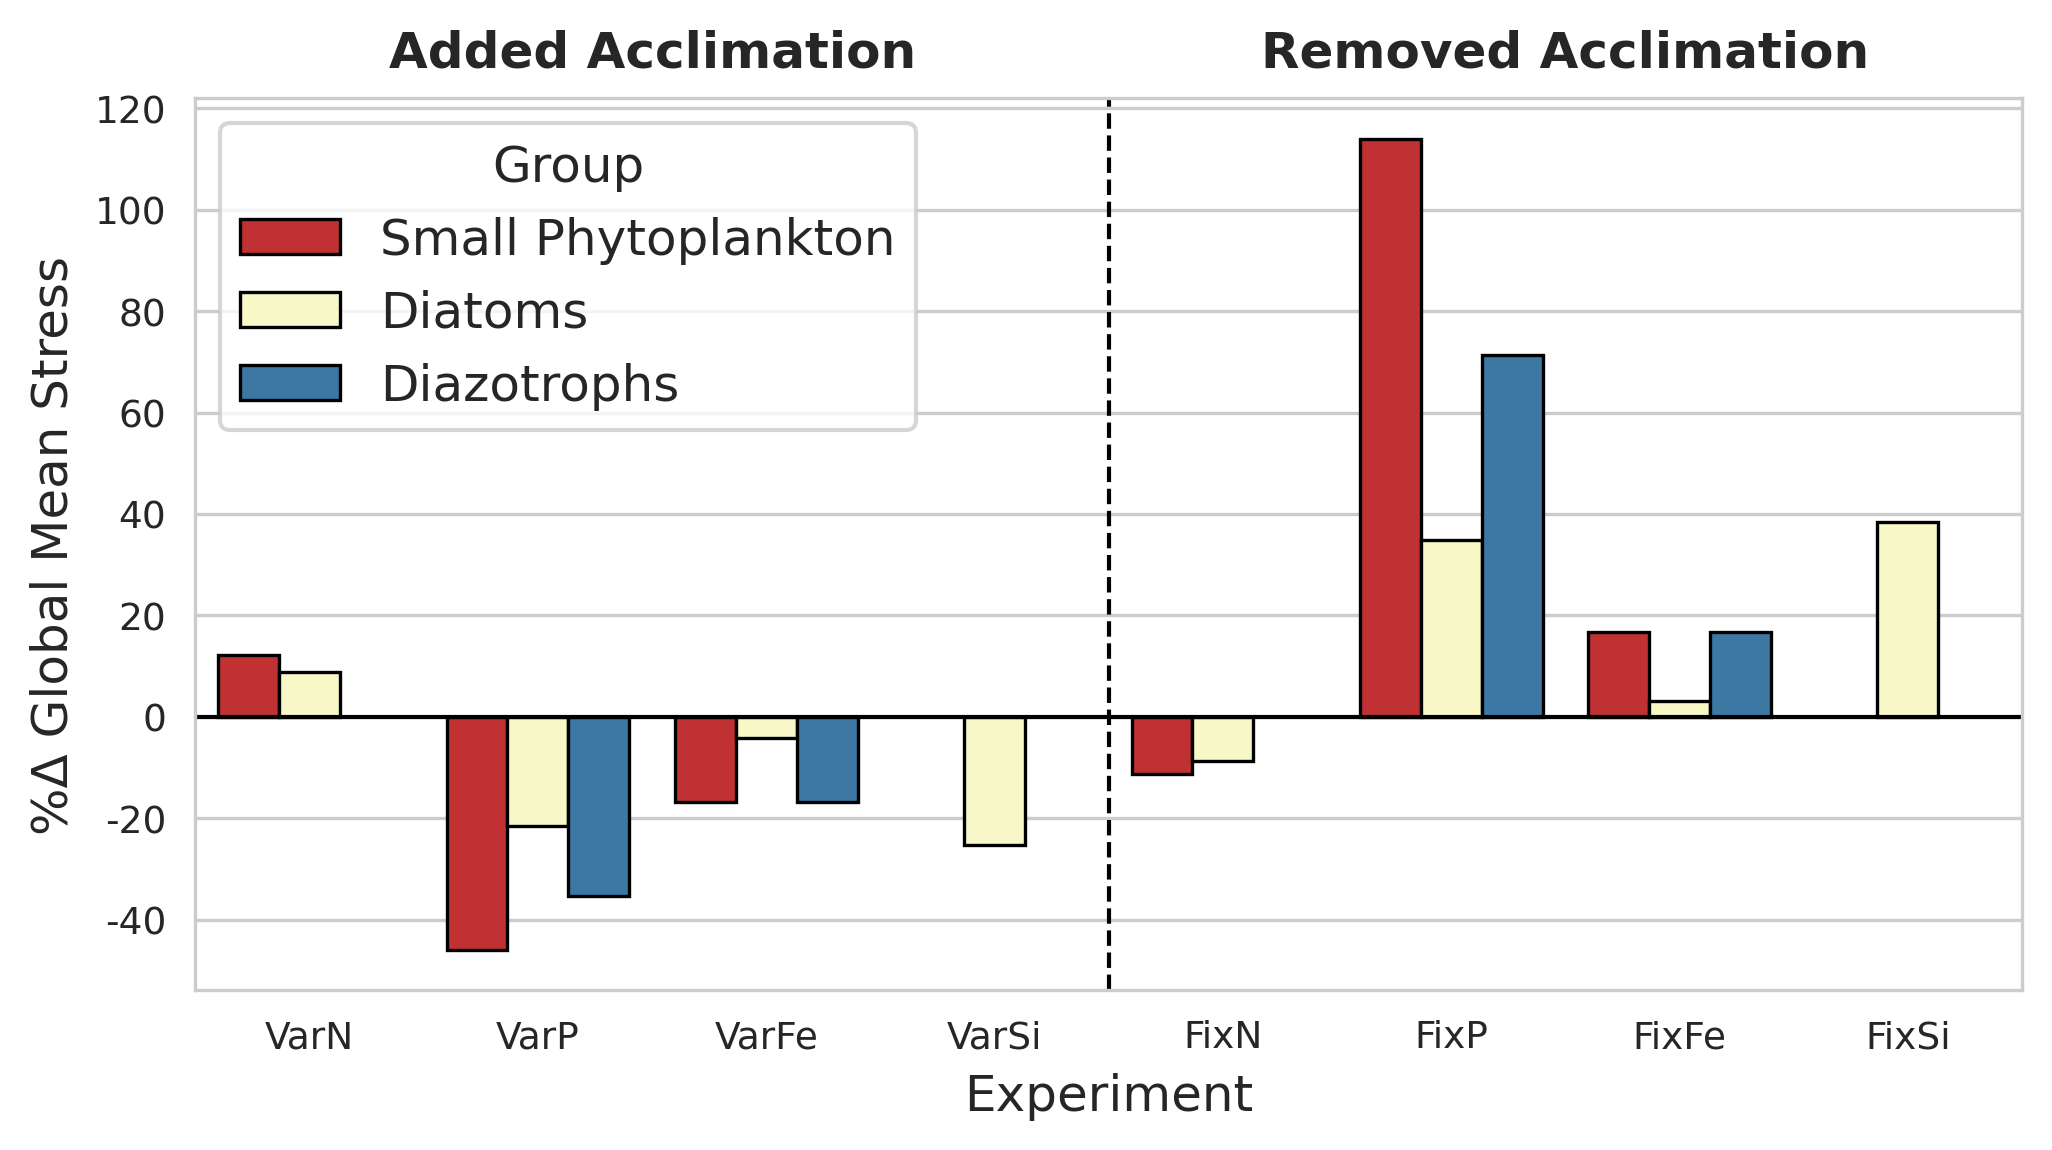

In [9]:
order = [
    "VarN",
    "VarP",
    "VarFe",
    "VarSi",
    "FixN",
    "FixP",
    "FixFe",
    "FixSi",
]
fig = plt.figure(figsize=(7,4), dpi=300)
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df,
    x="Experiment",
    y="Difference",
    hue="Group",
    order=order,
    palette=color_map,
    errorbar=None,
    edgecolor="black",
    linewidth=0.8
)

from matplotlib.ticker import FormatStrFormatter

ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))

ax.text(
    1.5,
    ax.get_ylim()[1]*1.05,
    "Added Acclimation",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    5.5,
    ax.get_ylim()[1]*1.05,
    "Removed Acclimation",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel("%Δ Global Mean Stress")

ax.axvline(3.5, color="k", linestyle="--", linewidth=1)

ax.axhline(0, color="black", linewidth=1)

plt.tight_layout()

file_name = f"figures/nut_acclim"
plt.savefig(file_name + ".png", dpi=300, bbox_inches='tight')
fig.savefig(file_name + ".svg")
print(f"Figure saved as {file_name}")
plt.show()